# Machine Learning Project 1

## Problem Description/Motivation

Heart disease is a very deadly yet easily traceable condition. Many factors of a person's life such as medical conditions, eating habits, exercise, and lifestyle can lead to an increased risk of heart disease. We want to be able to allow doctors to inform patients when they may be at a potential risk for heart disease. The goal of this project is to process patient data and train multiple classification models to predict whether a patient is at risk based on training data that we give to the models. Finally we will use that to get an accuracy score of how well the model predicts whether a test patient has or doesn't have a heart disease. 

## Data Collection/Processing/Standarization

Firstly, we process the heart.csv data set, convert the files to data frames using pandas, then concatenate all the data frames into one. We then display the data, showing the different variables or features we use to train the models. These features are age, sex, where 0 = female 1 = male, chest pain type 0-3, resting blood pressure in mm Hg, serum cholesterol in mg/dl, whether fasting blood sugar > 120 mg/dl is true or false, resting electrocardiographic results 0-2, maximum heart rate, exercise induced angina true or false, ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels colored by fluoroscopy 0-3, and thal where 1 is normal, 2 is fixed defect, and 3 is reversible defect. Our target is whether the patient has a heart disease true or false and the true or false values are represented with 0 or 1.

In [9]:
import glob
import pandas as pd
import os

# Check if the file exists directly instead of using glob
file_path = '../Machine-Learning-Project-1/heart.csv'

# Option 1: If you're sure about the file path, read it directly
if os.path.exists(file_path):
    data = pd.read_csv(file_path, sep=',')
else:
    # Option 2: Use a more general glob pattern if you're unsure about the exact path
    dataFiles = glob.glob('../**/heart.csv', recursive=True)
    
    # Print found files to debug
    print(f"Found files: {dataFiles}")
    
    if dataFiles:
        # If files were found, read and concatenate them
        data_list = []
        for file in dataFiles:
            data_list.append(pd.read_csv(file, sep=','))
        
        data = pd.concat(data_list)
    else:
        print("No files found. Please check the file path.")
        # Create an empty DataFrame as a fallback
        data = pd.DataFrame()

# Display the data
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


The next job is to split the data into training, validation, and test data. We save all the variable columns in X and save our target in y. We split the data once 80/20 to get training and test data and split the training data 75/25 so our final values are 60% training, 20% validation, and 20% test. Next we standardize using sklearn's StandardScaler and use this to fit on the training features and transform on the validation and test features.

In [10]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['target'])
y = data["target"]

# split the data into training and test sets, 80% training, 20% test
tempTrainX, testX, tempTrainY, testY = train_test_split(X, y, test_size = 0.2, random_state = 1)
# split training into validation (60% training, 20% validation, 20% test)
trainX, validationX, trainY, validationY = train_test_split(tempTrainX, tempTrainY, test_size = 0.25, random_state = 1)

# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit on training features
scaledTrainX = scaler.fit_transform(trainX)

# transform validation and test
scaledValidationX = scaler.transform(validationX)
scaledTestX = scaler.transform(testX)


## Baseline Model (Logistic Regression)

We must now create our baseline model. We do this using sklearn's LogisticRegression. We fit our baseline model using the scaledTrainX and trainY. We then get the train, validation, and test predictions to be used to find the accuracy scores. We then print them out, which our baseline model gets a test accuracy of around 0.81. Next we print the predicted class labels vs the actual class labels for viewing which labels our model is predicting correctly and which is falsely predicting. We then create a classification report which shows information such as precision, the ability to not label a negative sample as positive, recall, the ratio of correctly predicted samples vs all samples of that class, F1, harmonic mean of precision and recall, and support, the number of actual occurrences of the class. Lastly we create a confusion matrix, which shows the true label vs the predicted label to show the amount of true and false positives and negatives found. Our baseline model shows 30 false positives, 10 false negatives, and around 80 and 90 true positives and negatives.

Train Accuracy: 0.8682926829268293
Validation Accuracy: 0.8097560975609757
Test Accuracy: 0.8097560975609757

Predicted class labels:
 [0 1 1 1 0 1 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1
 0 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 1
 1 1 1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 0
 1 0 1 1 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 1 0 0
 0 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1 0 0
 0 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0]

True class labels:
 [0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1
 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0
 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 0
 0 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 0 0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0
 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0]

Classific

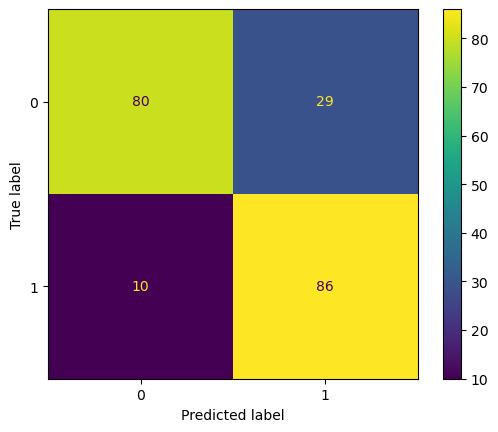

In [11]:
# logistic regression used as baseline model
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression()
baseline.fit(scaledTrainX, trainY)

# predictions
trainPrediction = baseline.predict(scaledTrainX)
validationPrediction = baseline.predict(scaledValidationX)
testPrediction = baseline.predict(scaledTestX)

# use accuracy score to show how close our model is to true classes
from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(trainY, trainPrediction))
print("Validation Accuracy:", accuracy_score(validationY, validationPrediction))
print("Test Accuracy:", accuracy_score(testY, testPrediction))

# print predicted and true class labels
print('\nPredicted class labels:\n', testPrediction)
print('\nTrue class labels:\n', testY.to_numpy())

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# print quality metrics
print('\nClassification Report:\n\n', classification_report(testY, testPrediction))

# confusion matrix
confusionMatrix = confusion_matrix(testY, testPrediction)
display = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
display.plot()


## Linear Basis Function

The next model we want to use is the Linear Basis Function. We wish to choose hyperparameters that will improve the accuracy compared to our baseline model. Our chosen hyperparameters are different polynomial degrees and different regularization parameters (C values) to use for our logisitic regression model. Our chosen polynomial degrees are 1 through 3 and our chosen C values are 0.01, 0.1, 1 (standard), and 10. We want to be able to track which combination of these parameters yields the best validation accuracy. We make variables to track which model gives the best accuracy and save the best degree, C value, model, and polynomial features. We loop through the different degrees to get the polynomial and interaction features, using include_bias=False to remove the 1 value. We then fit and transform using the scaled X to get the polynomial training and validation. Then we loop through the different C values to create the LogisticRegression models using C values and a max_iter of 1000 to ensure we find the optimal solution. We fit it with the polynomial training and predict the validation prediction to find the validationaccuracy score and print out the hyperparameters with it. If this combination of hyperparameters leads to a better accuracy we update the best variables. After looping through, we print the best found hyperparameters and accuracy and use that to transform using the best polynomial and use the best model to find the test prediction. Finally, we find and print the test accuracy, the predicited vs true class labels, classification report and confusion matrix.

Degree: 1 C: 0.01 Validation Accuracy: 0.8048780487804879
Degree: 1 C: 0.1 Validation Accuracy: 0.8097560975609757
Degree: 1 C: 1 Validation Accuracy: 0.8097560975609757
Degree: 1 C: 10 Validation Accuracy: 0.8146341463414634
Degree: 2 C: 0.01 Validation Accuracy: 0.8439024390243902
Degree: 2 C: 0.1 Validation Accuracy: 0.848780487804878
Degree: 2 C: 1 Validation Accuracy: 0.9463414634146341
Degree: 2 C: 10 Validation Accuracy: 0.975609756097561
Degree: 3 C: 0.01 Validation Accuracy: 0.9024390243902439
Degree: 3 C: 0.1 Validation Accuracy: 0.9658536585365853
Degree: 3 C: 1 Validation Accuracy: 1.0
Degree: 3 C: 10 Validation Accuracy: 1.0

Best Degree: 3
Best C Value: 1
Best Validation Accuracy: 1.0
Final Test Accuracy: 1.0

Predicted class labels:
 [0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1
 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0
 1 0 1 1 1 0 0 1

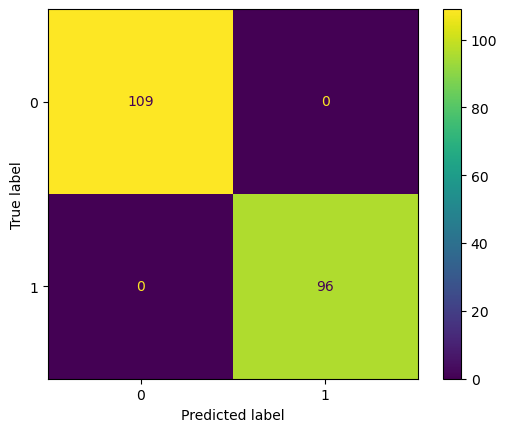

In [12]:
# use polynomial features for logistic regression to perform linear basis function
from sklearn.preprocessing import PolynomialFeatures

# desired hyperparameters degree and C value (regularization parameter)
degrees = [1, 2, 3]
cValues = [0.01, 0.1, 1, 10]

# variables to track to see what hyperparameters and model produce the best accuracy
bestValidationAcc = 0
bestDegree = 0
bestCValue = 0
bestModel = None
bestPoly = None

# test model using different hyperparamters
for d in degrees:
    
    # different polynomial to get polynomial and interaction features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    
    # fit and transform for training and validation model
    trainPoly = poly.fit_transform(scaledTrainX)
    validationPoly = poly.transform(scaledValidationX)
    
    # use different regularization parameters
    for c in cValues:

        # create and fit model using polynomial data, regularization parameters, and max iterations to find optimal solution
        model = LogisticRegression(C=c, max_iter=1000)
        model.fit(trainPoly, trainY)
        
        # predict to find validation prediction
        validationPrediction = model.predict(validationPoly)

        validationAcc = accuracy_score(validationY, validationPrediction)

        print("Degree:", d, "C:", c, "Validation Accuracy:", validationAcc)

        if validationAcc > bestValidationAcc:
            bestValidationAcc = validationAcc
            bestDegree = d
            bestC = c
            bestModel = model
            bestPoly = poly

print()
print("Best Degree:", bestDegree)
print("Best C Value:", bestC)
print("Best Validation Accuracy:", bestValidationAcc)

# transform using best polynomial and use the best model to find the test prediction
testPoly = bestPoly.transform(scaledTestX)
testPrediction = bestModel.predict(testPoly)

print("Final Test Accuracy:", accuracy_score(testY, testPrediction))

# print predicted and true class labels
print('\nPredicted class labels:\n', testPrediction)
print('\nTrue class labels:\n', testY.to_numpy())

# print quality metrics
print('\nClassification Report:\n\n', classification_report(testY, testPrediction))

# confusion matrix
confusionMatrix = confusion_matrix(testY, testPrediction)
display = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
display.plot()

## Kernel Ridge Regression

For our second primary model, we use Kernel Ridge Regression (sklearn KernelRidge). Since Kernel Ridge produces continuous outputs, we threshold the predictions at 0.5 to generate binary class labels. We tune two hyperparameters: the kernel type (linear, rbf, poly) and the regularization parameter alpha (0.01, 0.1, 1, 10). We track the best combination using validation accuracy, then evaluate the best model on the test set with a classification report and confusion matrix.

Kernel: linear, Alpha: 0.01, Validation Accuracy: 0.5659
Kernel: linear, Alpha: 0.1, Validation Accuracy: 0.5659
Kernel: linear, Alpha: 1, Validation Accuracy: 0.5659
Kernel: linear, Alpha: 10, Validation Accuracy: 0.5659
Kernel: rbf, Alpha: 0.01, Validation Accuracy: 0.9854
Kernel: rbf, Alpha: 0.1, Validation Accuracy: 0.9610
Kernel: rbf, Alpha: 1, Validation Accuracy: 0.9024
Kernel: rbf, Alpha: 10, Validation Accuracy: 0.7805
Kernel: poly, Alpha: 0.01, Validation Accuracy: 0.9756
Kernel: poly, Alpha: 0.1, Validation Accuracy: 0.9805
Kernel: poly, Alpha: 1, Validation Accuracy: 0.9268
Kernel: poly, Alpha: 10, Validation Accuracy: 0.8634

Best Kernel: rbf
Best Alpha: 0.01
Best Validation Accuracy: 0.9853658536585366
Final Test Accuracy: 1.0

Predicted class labels:
 [0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1
 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 

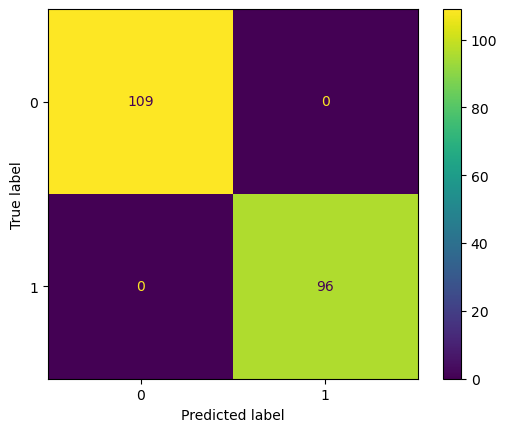

In [13]:
from sklearn.kernel_ridge import KernelRidge

# hyperparameters to tune
alphas = [0.01, 0.1, 1, 10]
kernels = ['linear', 'rbf', 'poly']

# variables to track best model
bestKRValidationAcc = 0
bestKRAlpha = None
bestKRKernel = None
bestKRModel = None

for k in kernels:
    for a in alphas:
        model = KernelRidge(alpha=a, kernel=k)
        model.fit(scaledTrainX, trainY)

        # threshold continuous output at 0.5 for binary classification
        validationPrediction = (model.predict(scaledValidationX) >= 0.5).astype(int)
        validationAcc = accuracy_score(validationY, validationPrediction)

        print(f'Kernel: {k}, Alpha: {a}, Validation Accuracy: {validationAcc:.4f}')

        if validationAcc > bestKRValidationAcc:
            bestKRValidationAcc = validationAcc
            bestKRAlpha = a
            bestKRKernel = k
            bestKRModel = model

print()
print('Best Kernel:', bestKRKernel)
print('Best Alpha:', bestKRAlpha)
print('Best Validation Accuracy:', bestKRValidationAcc)

# evaluate on test set
krTestPrediction = (bestKRModel.predict(scaledTestX) >= 0.5).astype(int)
print('Final Test Accuracy:', accuracy_score(testY, krTestPrediction))

# predicted vs true
print('\nPredicted class labels:\n', krTestPrediction)
print('\nTrue class labels:\n', testY.to_numpy())

# classification report
print('\nClassification Report:\n\n', classification_report(testY, krTestPrediction))

# confusion matrix
confusionMatrix = confusion_matrix(testY, krTestPrediction)
display = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
display.plot()


## Model Comparison

Now that we have trained and tuned all models, we compare their test set performance side by side. We report accuracy, F1-score, and ROC-AUC for the baseline logistic regression, the tuned Linear Basis Function model, and the tuned Kernel Ridge Regression model. We also plot ROC curves for each model to visualize their performance.

Model                            Accuracy   F1 Score    ROC-AUC
-----------------------------------------------------------------
Baseline (Logistic Reg)            0.8098     0.8152     0.9154
Linear Basis Function              1.0000     1.0000     1.0000
Kernel Ridge Regression            1.0000     1.0000     1.0000


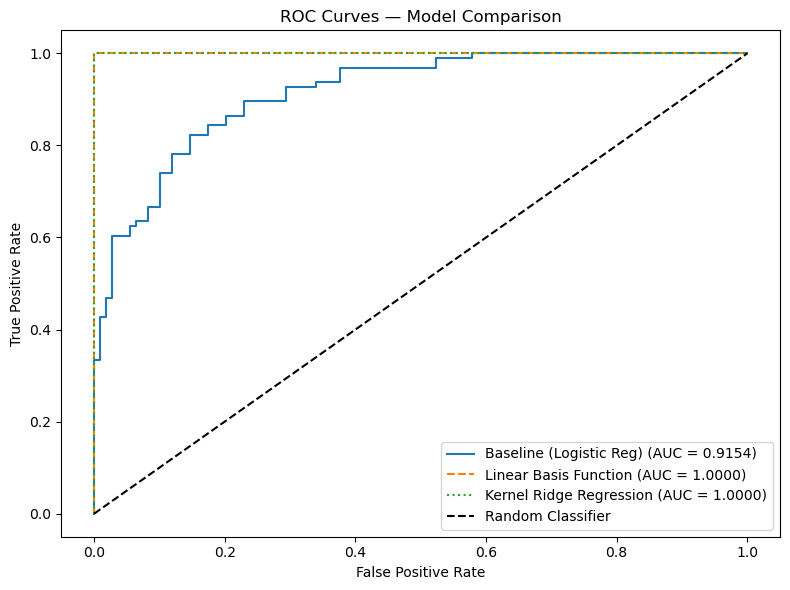

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# --- collect results for each model ---

# baseline logistic regression
baselineTestPred = baseline.predict(scaledTestX)
baselineTestProba = baseline.predict_proba(scaledTestX)[:, 1]

# LBF best model
lbfTestPoly = bestPoly.transform(scaledTestX)
lbfTestPred = bestModel.predict(lbfTestPoly)
lbfTestProba = bestModel.predict_proba(lbfTestPoly)[:, 1]

# Kernel Ridge best model
krTestPred = (bestKRModel.predict(scaledTestX) >= 0.5).astype(int)
krTestProba = bestKRModel.predict(scaledTestX)

models = ['Baseline (Logistic Reg)', 'Linear Basis Function', 'Kernel Ridge Regression']
preds  = [baselineTestPred, lbfTestPred, krTestPred]
probas = [baselineTestProba, lbfTestProba, krTestProba]

print(f"{'Model':<30} {'Accuracy':>10} {'F1 Score':>10} {'ROC-AUC':>10}")
print('-' * 65)
for name, pred, proba in zip(models, preds, probas):
    acc = accuracy_score(testY, pred)
    f1  = f1_score(testY, pred)
    auc = roc_auc_score(testY, proba)
    print(f"{name:<30} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}")

# --- ROC Curves ---
plt.figure(figsize=(8, 6))
# different line styles for each model to avoid overlapping
styles = ['-', '--', ':']
for name, proba, style in zip(models, probas, styles):
    fpr, tpr, _ = roc_curve(testY, proba)
    auc = roc_auc_score(testY, proba)
    plt.plot(fpr, tpr, linestyle=style, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Conclusions

In this project, we trained and compared three models to predict heart disease from patient clinical data: a baseline logistic regression, a tuned Linear Basis Function model (polynomial logistic regression), and a tuned Kernel Ridge Regression model. While our baseline model's test accuracy is fairly decent, in a potentially life-threatening situation like heart disease, this just isn't close enough. Our other 2 tuned models show that with proper hyperparameter choice such as polynomial degrees, kernel types, and regulation parameters for both models, we can massively improve our test accuracy to where both models can 100% correctly predict whether a person does or does not have a heart disease or at risk for one using the newly implemented tuning.